# Cryptocurrency Market Analysis and Price Prediction Using Machine Learning & Deep Learing

## Introduction

The cryptocurrency market has experienced rapid growth and significant volatility in recent years, making it an important area for financial analysis and predictive modeling. Cryptocurrencies such as Bitcoin, Ethereum, Binance Coin, XRP, and Cardano have become widely traded digital assets across global financial markets.

This project focuses on analyzing historical cryptocurrency price data using exploratory data analysis (EDA) techniques and machine learning models. The dataset was collected using the yfinance library, covering price movements from 2020 to 2024. Various analytical methods such as price trend visualization, daily return analysis, correlation heatmaps, and distribution plots were used to understand market behavior and relationships between different cryptocurrencies.

After performing the exploratory analysis, a detailed study of Bitcoin was conducted to prepare the data for predictive modeling. Machine learning techniques including Long Short-Term Memory (LSTM) and other forecasting algorithms are used to analyze historical patterns and generate future price predictions.The objective of this project is to gain insights into cryptocurrency market trends and demonstrate how data science and machine learning techniques can be applied for financial forecasting.

## Importing Libraries

In [7]:
import pandas as pd
import numpy as np
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

plt.style.use('seaborn')


## Download Cryptocurrency Dataset

In [5]:
cryptos = ['BTC-USD','ETH-USD','BNB-USD','XRP-USD','ADA-USD']
data = yf.download(cryptos, start="2020-01-01", end="2024-01-01")

data.head()

[*********************100%***********************]  5 of 5 completed


Price          Close                                                    High  \
Ticker       ADA-USD    BNB-USD      BTC-USD     ETH-USD   XRP-USD   ADA-USD   
Date                                                                           
2020-01-01  0.033458  13.689083  7200.174316  130.802002  0.192667  0.033813   
2020-01-02  0.032751  13.027011  6985.470215  127.410179  0.188043  0.033507   
2020-01-03  0.034180  13.660452  7344.884277  134.171707  0.193521  0.034427   
2020-01-04  0.034595  13.891512  7410.656738  135.069366  0.194355  0.034685   
2020-01-05  0.034721  14.111019  7411.317383  136.276779  0.195537  0.035356   

Price                                                     ...      Open  \
Ticker        BNB-USD      BTC-USD     ETH-USD   XRP-USD  ...   ADA-USD   
Date                                                      ...             
2020-01-01  13.873946  7254.330566  132.835358  0.194362  ...  0.032832   
2020-01-02  13.715548  7212.155273  130.820038  0.192896  ...  0.033474   
2020-01-03  13.763709  7413.715332  134.554016  0.194070  ...  0.032748   
2020-01-04  13.921914  7427.385742  136.052719  0.194653  ...  0.034191   
2020-01-05  14.410801  7544.497070  139.410202  0.199223  ...  0.034574   

Price                                                       Volume             \
Ticker        BNB-USD      BTC-USD     ETH-USD   XRP-USD   ADA-USD    BNB-USD   
Date                                                                            
2020-01-01  13.730962  7194.892090  129.630661  0.192912  22948374  172980718   
2020-01-02  13.698126  7202.551270  130.820038  0.192708  20843934  156376427   
2020-01-03  13.035329  6984.428711  127.411263  0.187948  30162644  173683857   
2020-01-04  13.667442  7345.375488  134.168518  0.193521  29535781  182230374   
2020-01-05  13.888340  7410.451660  135.072098  0.194367  21479178  202552703   

Price                                             
Ticker          BTC-USD      ETH-USD     XRP-USD  
Date                                              
2020-01-01  18565664997   7935230330  1041134003  
2020-01-02  20802083465   8032709256  1085351426  
2020-01-03  28111481032  10476845358  1270017043  
2020-01-04  18444271275   7430904515   999331594  
2020-01-05  19725074095   7526675353  1168067557  

[5 rows x 25 columns]

## Basic Data Information

In [38]:
print("Dataset Info")
data.info()

print("Summary Statistics")
data.describe()

print("Missing Values")
print(data.isnull().sum())

print("Summary of Colums")
print(data.columns)

Dataset Info
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1461 entries, 2020-01-01 to 2023-12-31
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, ADA-USD)   1461 non-null   float64
 1   (Close, BNB-USD)   1461 non-null   float64
 2   (Close, BTC-USD)   1461 non-null   float64
 3   (Close, ETH-USD)   1461 non-null   float64
 4   (Close, XRP-USD)   1461 non-null   float64
 5   (High, ADA-USD)    1461 non-null   float64
 6   (High, BNB-USD)    1461 non-null   float64
 7   (High, BTC-USD)    1461 non-null   float64
 8   (High, ETH-USD)    1461 non-null   float64
 9   (High, XRP-USD)    1461 non-null   float64
 10  (Low, ADA-USD)     1461 non-null   float64
 11  (Low, BNB-USD)     1461 non-null   float64
 12  (Low, BTC-USD)     1461 non-null   float64
 13  (Low, ETH-USD)     1461 non-null   float64
 14  (Low, XRP-USD)     1461 non-null   float64
 15  (Open, ADA-USD)    1461 non-null   float6

## Extract Closing Prices

In [9]:
close_prices = data['Close']

close_prices.head()

Ticker,ADA-USD,BNB-USD,BTC-USD,ETH-USD,XRP-USD
Date,,,,,
2020-01-01,0.033458,13.689083,7200.174316,130.802002,0.192667
2020-01-02,0.032751,13.027011,6985.470215,127.410179,0.188043
2020-01-03,0.034180,13.660452,7344.884277,134.171707,0.193521
2020-01-04,0.034595,13.891512,7410.656738,135.069366,0.194355
2020-01-05,0.034721,14.111019,7411.317383,136.276779,0.195537


## Price Trend Visualization

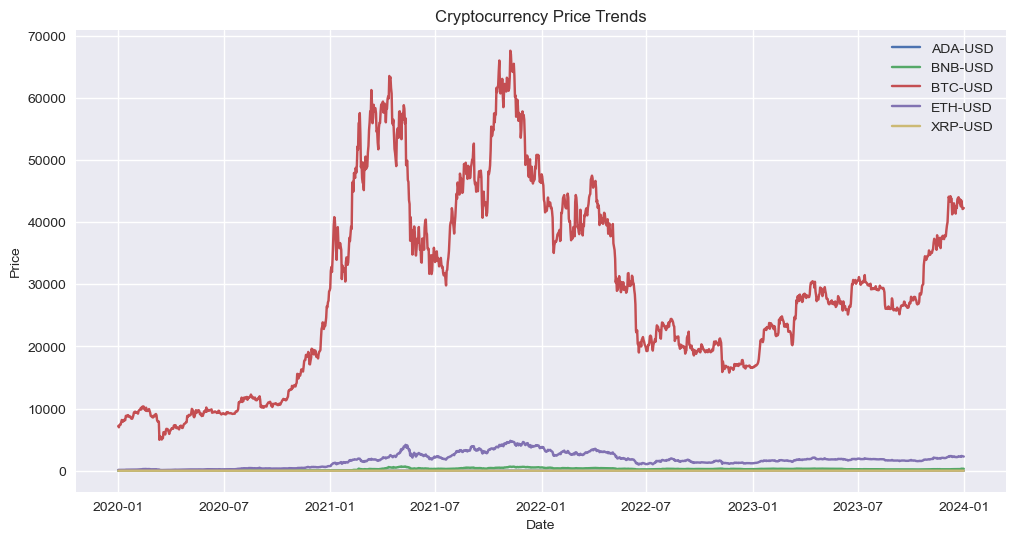

In [10]:
plt.figure(figsize=(12,6))

for crypto in close_prices.columns:
    plt.plot(close_prices[crypto], label=crypto)

plt.title("Cryptocurrency Price Trends")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()


## Daily Returns

In [13]:
returns = close_prices.pct_change()

returns.head()


Ticker,ADA-USD,BNB-USD,BTC-USD,ETH-USD,XRP-USD
Date,,,,,
2020-01-01,NaN,NaN,NaN,NaN,NaN
2020-01-02,-0.021131,-0.048365,-0.029819,-0.025931,-0.024000
2020-01-03,0.043632,0.048625,0.051452,0.053069,0.029132
2020-01-04,0.012142,0.016915,0.008955,0.006690,0.004310
2020-01-05,0.003642,0.015802,0.000089,0.008939,0.006082


## Daily Returns Visualization

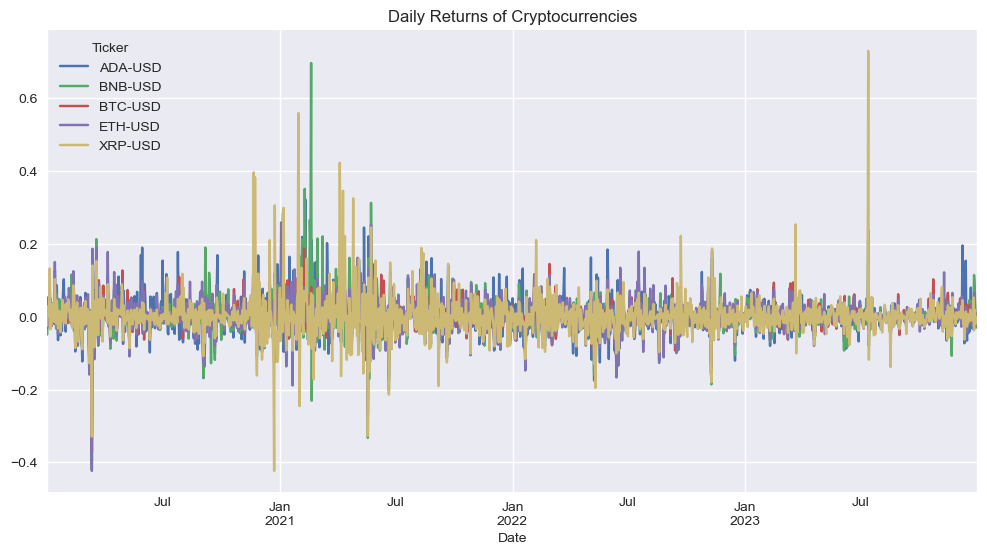

In [40]:

returns.plot(figsize=(12,6))
plt.title("Daily Returns of Cryptocurrencies")
plt.show()

## Correlation Heatmap

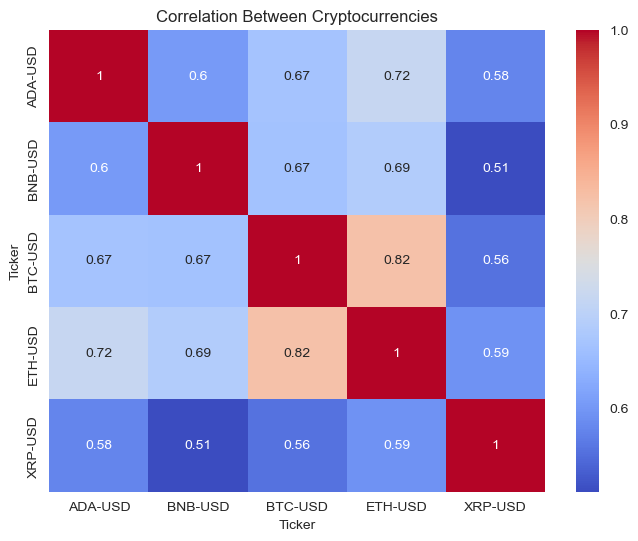

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(returns.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Cryptocurrencies")
plt.show()


## Trading Volume Analysis

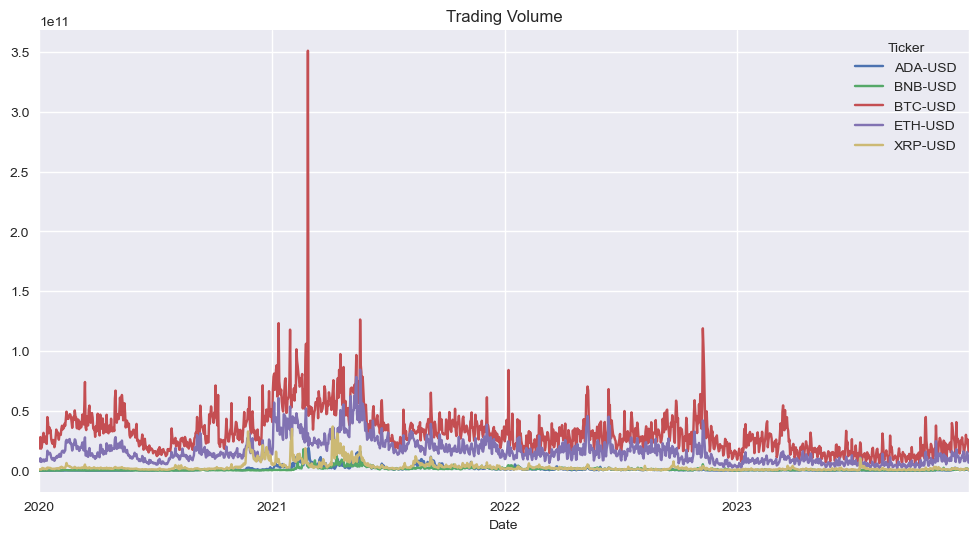

In [16]:
volume = data['Volume']

volume.plot(figsize=(12,6))
plt.title("Trading Volume")
plt.show()


## Price Trend Analysis

[*********************100%***********************]  5 of 5 completed


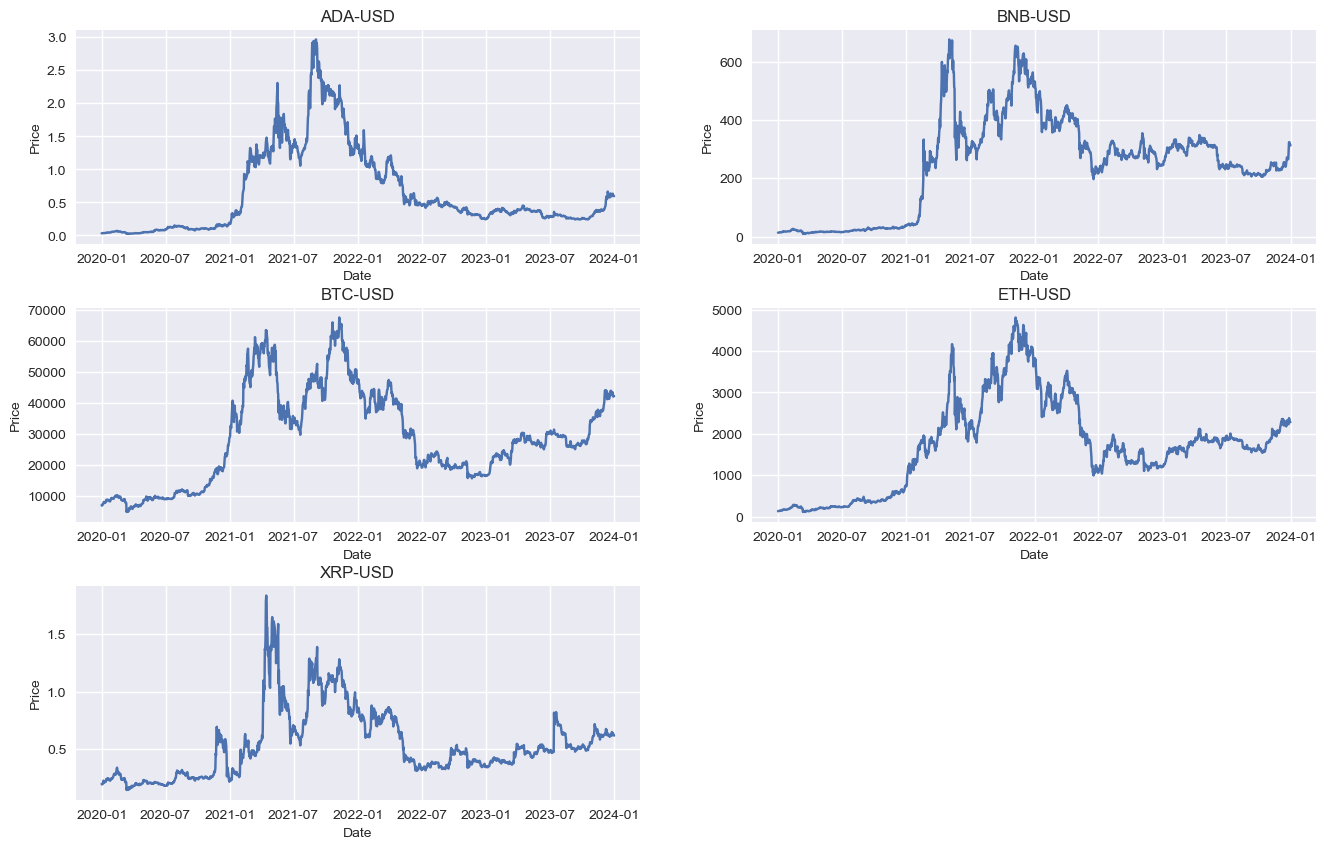

In [37]:
sns.set_style("darkgrid")

cryptos = ['BTC-USD','ETH-USD','BNB-USD','XRP-USD','ADA-USD']

data = yf.download(cryptos, start="2020-01-01", end="2024-01-01")

# Extract closing prices
close_prices = data['Close']

fig, axs = plt.subplots(3,2, figsize=(16,10),
                        gridspec_kw={'hspace':0.3,'wspace':0.2})

axs = axs.flatten()

for i, crypto in enumerate(close_prices.columns):

    axs[i].plot(close_prices[crypto])
    axs[i].set_title(crypto)
    axs[i].set_xlabel("Date")
    axs[i].set_ylabel("Price")

# Remove empty plot
fig.delaxes(axs[5])

plt.show()


## Daily Returns (Relative Price Changes) of Cryptocurrencies

[*********************100%***********************]  5 of 5 completed


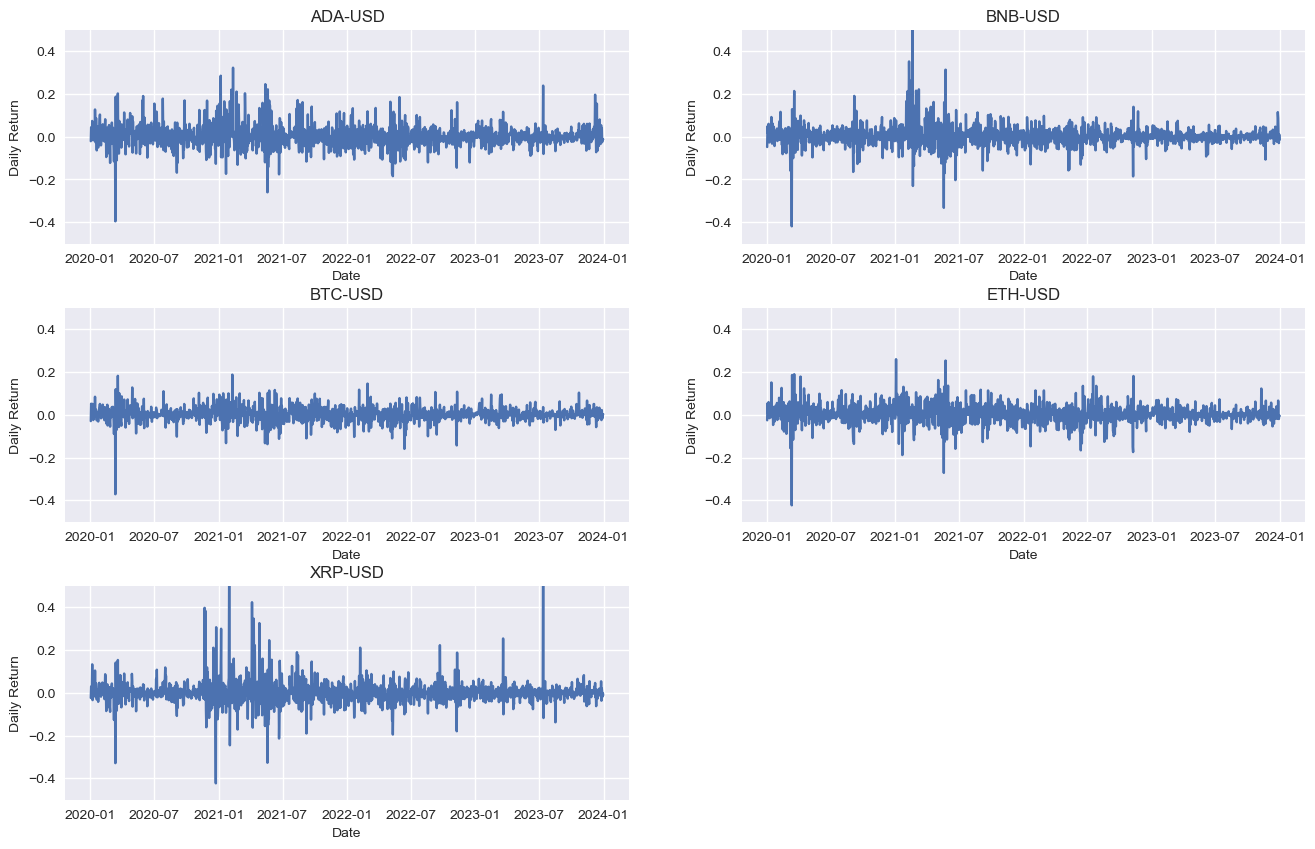

In [23]:
sns.set_style("darkgrid")

cryptos = ['BTC-USD','ETH-USD','BNB-USD','XRP-USD','ADA-USD']
data = yf.download(cryptos, start='2020-01-01', end='2024-01-01')
close_prices = data['Close']

# calculate daily returns
returns = close_prices.pct_change().dropna()
returns.head()

fig, axs = plt.subplots(3,2, figsize=(16,10),
                        gridspec_kw={'hspace':0.3,'wspace':0.2})

axs = axs.flatten()

for i, crypto in enumerate(returns.columns):

    axs[i].plot(returns[crypto])
    axs[i].set_title(crypto)
    axs[i].set_ylim([-0.5,0.5])
    axs[i].set_xlabel("Date")
    axs[i].set_ylabel("Daily Return")


fig.delaxes(axs[5])

plt.show()


## Distribution of Daily Returns 


[*********************100%***********************]  5 of 5 completed


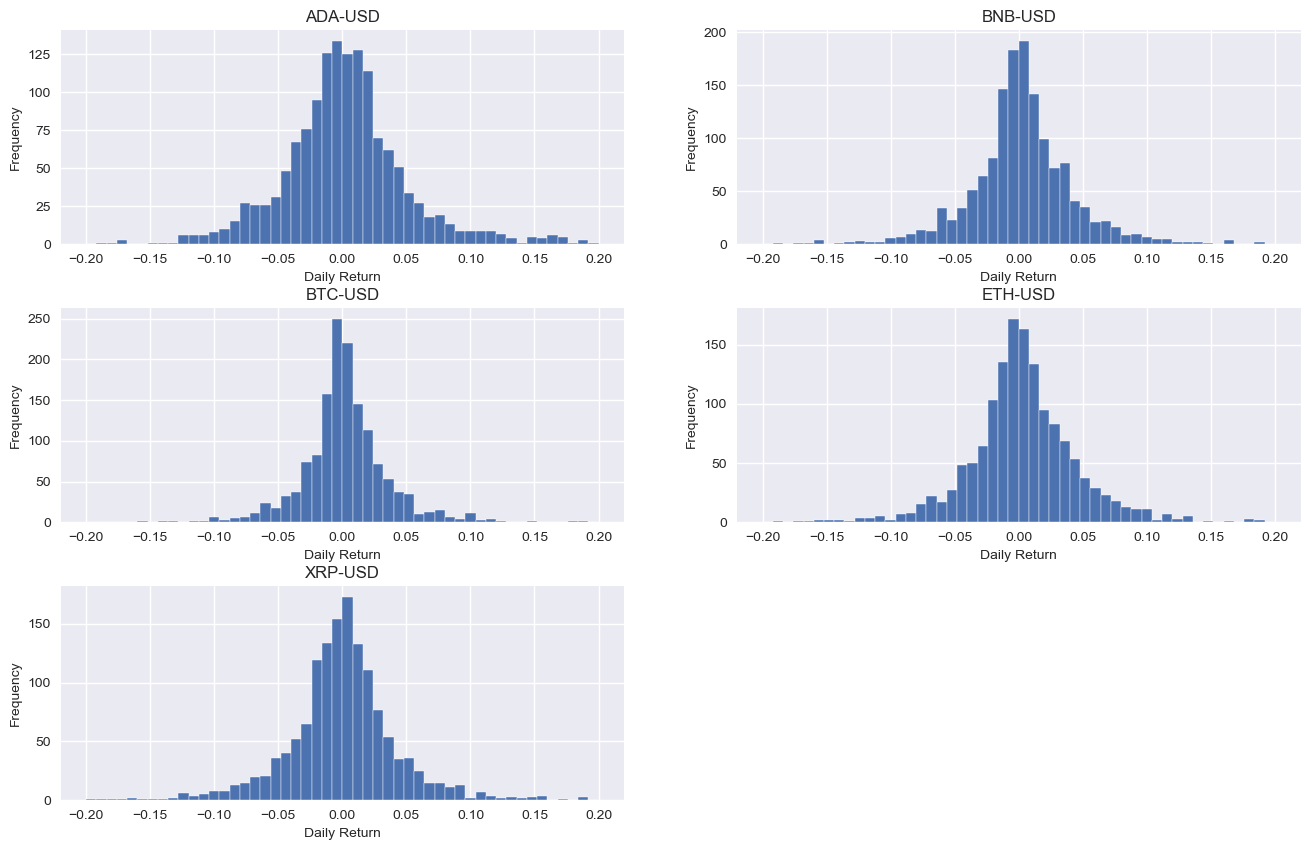

In [24]:
sns.set_style("darkgrid")

cryptos = ['BTC-USD','ETH-USD','BNB-USD','XRP-USD','ADA-USD']
data = yf.download(cryptos, start='2020-01-01', end='2024-01-01')
close_prices = data['Close']


returns = close_prices.pct_change().dropna()
fig, axs = plt.subplots(3,2, figsize=(16,10),
                        gridspec_kw={'hspace':0.3,'wspace':0.2})

axs = axs.flatten()

for i, crypto in enumerate(returns.columns):

    axs[i].hist(returns[crypto], bins=50, range=(-0.2,0.2))
    axs[i].set_title(crypto)
    axs[i].set_xlabel("Daily Return")
    axs[i].set_ylabel("Frequency")

# remove empty subplot
fig.delaxes(axs[5])

plt.show()


## Single Cryptocurrency Analysis (Bitcoin)

In [25]:
btc = yf.download('BTC-USD', start='2020-01-01', end='2024-01-01')
btc = btc[['Close']]
btc.head()

[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,BTC-USD
Date,
2020-01-01,7200.174316
2020-01-02,6985.470215
2020-01-03,7344.884277
2020-01-04,7410.656738
2020-01-05,7411.317383


## Visualize Bitcoin Price

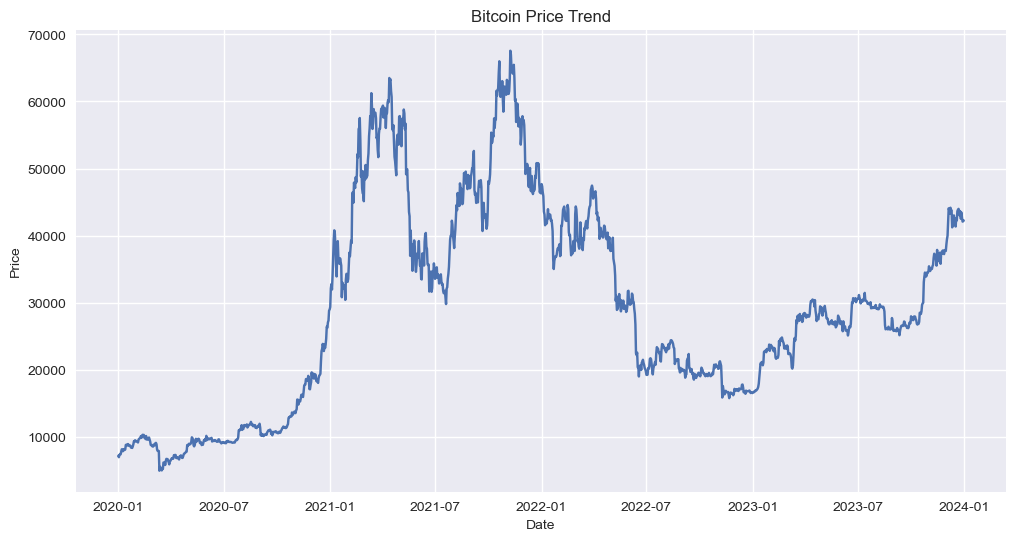

In [26]:
plt.figure(figsize=(12,6))

plt.plot(btc['Close'])

plt.title("Bitcoin Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()


## Bitcoin Daily Return Analysis

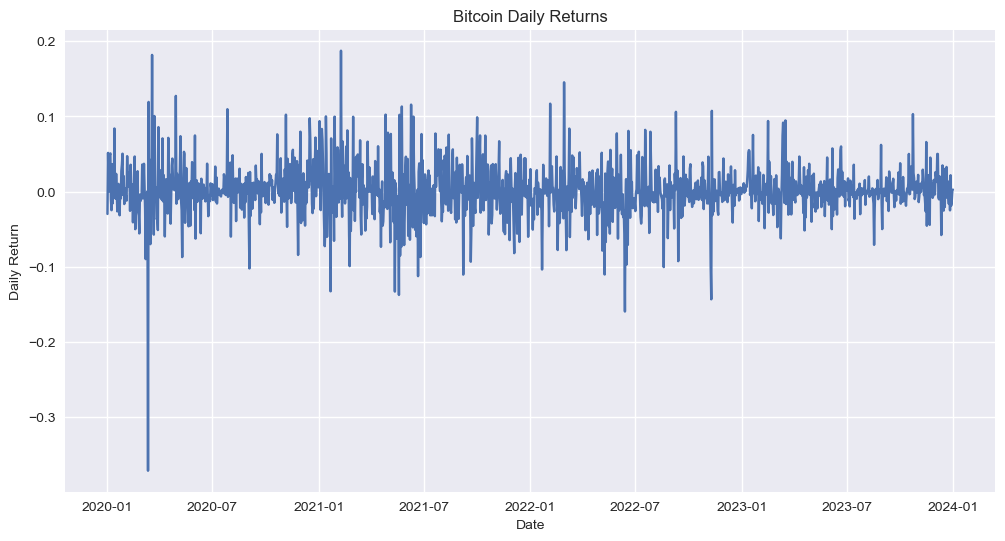

In [29]:
btc_returns = btc.pct_change()

plt.figure(figsize=(12,6))

plt.plot(btc_returns)

plt.title("Bitcoin Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.show()



## Distribution of Bitcoin Daily Returns

[*********************100%***********************]  1 of 1 completed


Price              Close          High           Low          Open  \
Ticker           BTC-USD       BTC-USD       BTC-USD       BTC-USD   
Date                                                                 
2023-12-27  43442.855469  43683.160156  42167.582031  42518.468750   
2023-12-28  42627.855469  43804.781250  42318.550781  43468.199219   
2023-12-29  42099.402344  43124.324219  41424.062500  42614.644531   
2023-12-30  42156.902344  42584.125000  41556.226562  42091.753906   
2023-12-31  42265.187500  42860.937500  41998.253906  42152.097656   

Price            Volume  
Ticker          BTC-USD  
Date                     
2023-12-27  25260941032  
2023-12-28  22992093014  
2023-12-29  26000021055  
2023-12-30  16013925945  
2023-12-31  16397498810  

------------ Open vs Close ------------
Price               Open         Close
Ticker           BTC-USD       BTC-USD
Date                                  
2023-12-27  42518.468750  43442.855469
2023-12-28  43468.199219  42627.85

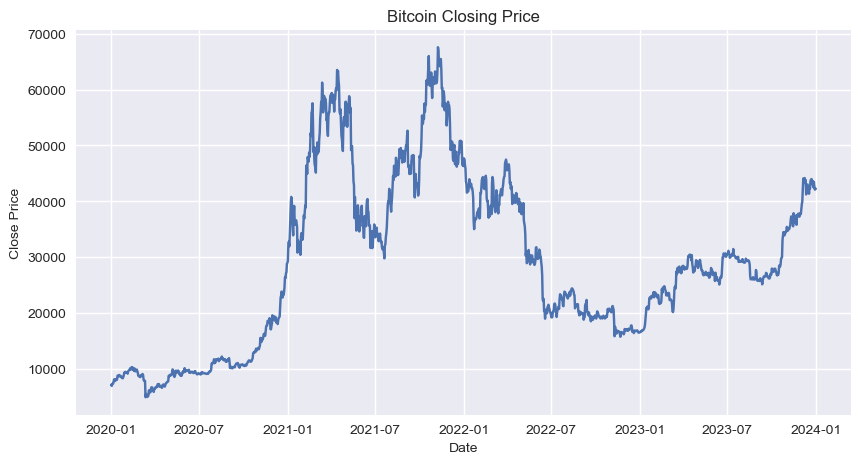

In [36]:
data_btc =yf.download('BTC-USD', start='2020-01-01', end='2024-01-01')
print(data_btc.tail())

print("\n------------ Open vs Close ------------")
print(data_btc[['Open','Close']].tail())
plt.figure(figsize=(10,5))

plt.plot(data_btc['Close'])

plt.title("Bitcoin Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.show()


## Moving Average Analysis

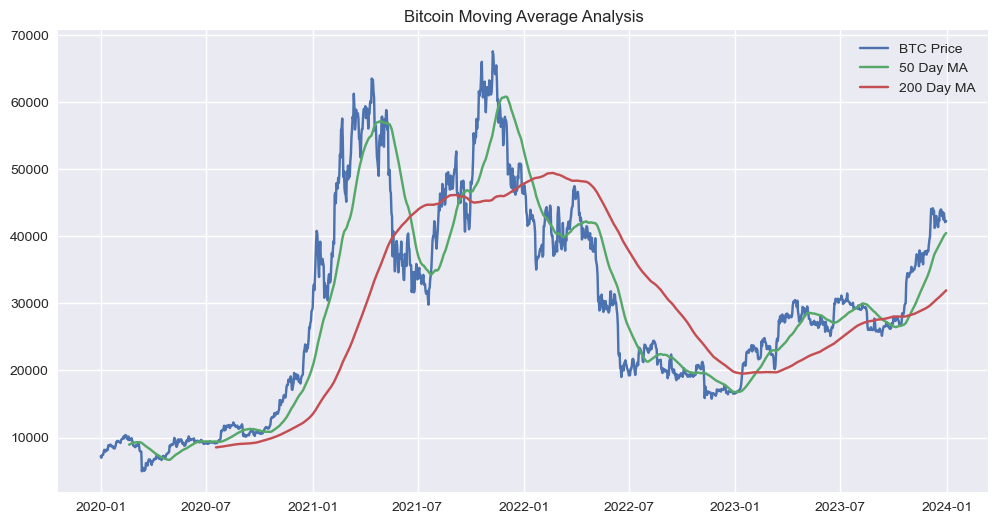

In [42]:
btc = close_prices['BTC-USD']

ma50 = btc.rolling(50).mean()
ma200 = btc.rolling(200).mean()

plt.figure(figsize=(12,6))

plt.plot(btc, label="BTC Price")
plt.plot(ma50, label="50 Day MA")
plt.plot(ma200, label="200 Day MA")

plt.title("Bitcoin Moving Average Analysis")

plt.legend()

plt.show()


## Rolling Volatility 

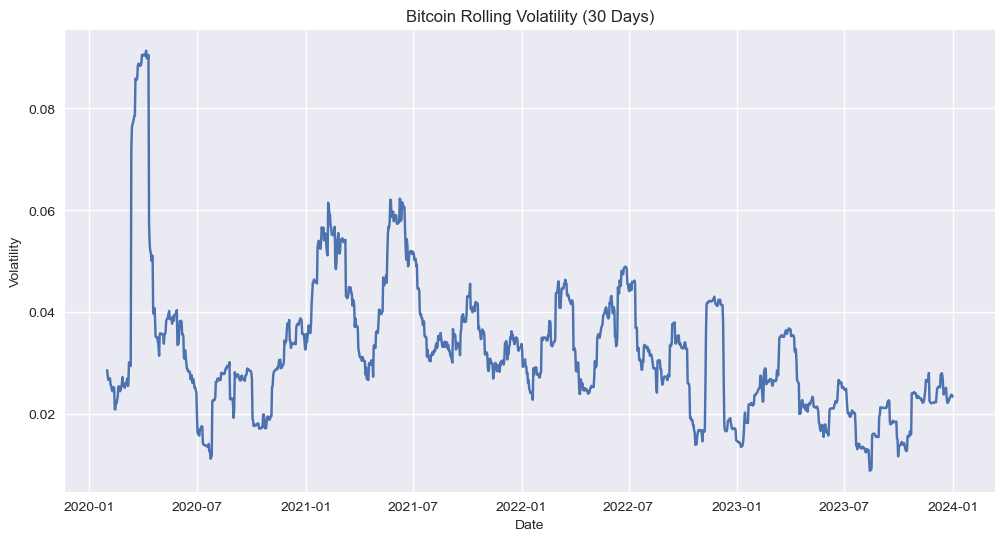

In [43]:
volatility = returns.rolling(30).std()

plt.figure(figsize=(12,6))

plt.plot(volatility['BTC-USD'])

plt.title("Bitcoin Rolling Volatility (30 Days)")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.show()


## Conclusion 

This project presented an exploratory data analysis and predictive modeling study of major cryptocurrencies. Historical market data for Bitcoin, Ethereum, Binance Coin, XRP, and Cardano was collected and analyzed to understand price trends, daily returns, and relationships among different digital assets.

The exploratory analysis revealed that cryptocurrency markets exhibit high volatility and strong correlations among major coins. Visualization techniques helped identify significant price fluctuations and trading patterns over time. Among the analyzed assets, Bitcoin showed dominant market influence and was selected for deeper analysis and prediction.
Using machine learning techniques, particularly the Long Short-Term Memory (LSTM) model, historical price data was used to forecast potential future price trends. The results demonstrate that deep learning models can effectively capture temporal patterns in financial time-series data.

Overall, this study highlights the usefulness of data analysis and machine learning in understanding cryptocurrency markets and supporting data-driven investment insights. Future work could incorporate additional features such as market sentiment, macroeconomic indicators, and longer historical datasets to further improve prediction accuracy